<a href="https://colab.research.google.com/github/aj277490-tech/CUU-MIT725/blob/main/Copy_of_judith_277490_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kampala Weather Data Analysis

In [ ]:
import pandas as pd

# URL for the raw CSV data
data_url = 'https://raw.githubusercontent.com/mkumakech/mkuma/master/Kampalanew.csv'

# Load the data into a pandas DataFrame
df = pd.read_csv(data_url)

print("Data loaded successfully. Here are the first 5 rows:")
display(df.head())

Data loaded successfully. Here are the first 5 rows:


,Unnamed: 0,station_ID,Date,Time,Day,Month,Year,TC,TdC,Hr,ddd,ffkmh,Precmm,Prechrs,Nt,Nh,HKm,Viskm
0,2,63680,31/12/2022 15:00,15:00:00,31,12,2022,25.0,17.5,63.0,CAL,0.0,0.0/3h,3h,6,4.0,0.6,8
1,3,63680,31/12/2022 12:00,12:00:00,31,12,2022,26.0,17.6,60.0,ENE,7.4,0.0/6h,6h,4,4.0,0.6,7
2,4,63680,31/12/2022 09:00,09:00:00,31,12,2022,22.5,18.2,77.0,CAL,0.0,0.0/3h,3h,7,5.0,0.3,6
3,5,63680,31/12/2022 06:00,06:00:00,31,12,2022,20.5,18.3,87.0,CAL,0.0,0.0/24h,24h,6,3.0,0.3,6
4,6,63680,30/12/2022 12:00,12:00:00,30,12,2022,26.4,17.4,58.0,SSE,7.4,0.0/6h,6h,4,5.0,0.6,10


Now that the data is loaded, let's inspect its structure and identify any missing values. This will help us with data cleaning.

In [ ]:
print("DataFrame Info:")
df.info()

print("\nMissing values count per column:")
display(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1009 non-null   int64  
 1   station_ID  1009 non-null   int64  
 2   Date        1009 non-null   object 
 3   Time        1009 non-null   object 
 4   Day         1009 non-null   int64  
 5   Month       1009 non-null   int64  
 6   Year        1009 non-null   int64  
 7   TC          1004 non-null   float64
 8   TdC         1007 non-null   float64
 9   Hr          1003 non-null   float64
 10  ddd         1009 non-null   object 
 11  ffkmh       1009 non-null   float64
 12  Precmm      1005 non-null   object 
 13  Prechrs     1005 non-null   object 
 14  Nt          1009 non-null   int64  
 15  Nh          1008 non-null   float64
 16  HKm         1009 non-null   float64
 17  Viskm       1009 non-null   int64  
dtypes: float64(6), int64(7), object(5)
memory usage: 142

,0
Unnamed: 0,0
station_ID,0
Date,0
Time,0
Day,0
Month,0
Year,0
TC,5
TdC,2
Hr,6


### Data Cleaning: Dropping Redundant Columns and Converting Date/Time

First, I will drop the 'Unnamed: 0' column as it appears to be an index artifact. Then, I'll combine the 'Date' and 'Time' columns into a single datetime column and set it as the DataFrame's index. This will facilitate time-series analysis.

In [ ]:
# Drop the 'Unnamed: 0' column
df = df.drop(columns=['Unnamed: 0'])

# Combine 'Date' and 'Time' into a single datetime column
df['DateTime'] = pd.to_datetime(df['Date'].str.split(' ').str[0] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

# Set 'DateTime' as the index and sort it
df = df.set_index('DateTime').sort_index()

# Drop the original 'Date' and 'Time' columns as they are now redundant
df = df.drop(columns=['Date', 'Time'])

print("DataFrame after dropping 'Unnamed: 0' and setting 'DateTime' index:")
display(df.head())
print("\nUpdated DataFrame Info:")
df.info()

DataFrame after dropping 'Unnamed: 0' and setting 'DateTime' index:


,station_ID,Day,Month,Year,TC,TdC,Hr,ddd,ffkmh,Precmm,Prechrs,Nt,Nh,HKm,Viskm
DateTime,,,,,,,,,,,,,,,
2022-01-01 06:00:00,63680,1,1,2022,19.6,19.0,96.0,SSE,14.4,2.0/24h,24h,8,5.0,0.3,6
2022-01-01 09:00:00,63680,1,1,2022,21.5,17.8,79.0,S,11.1,0.0/3h,3h,8,5.0,0.3,9
2022-01-01 12:00:00,63680,1,1,2022,25.0,17.5,63.0,S,7.4,0.0/6h,6h,4,4.0,0.6,10
2022-01-04 12:00:00,63680,4,1,2022,26.0,14.8,50.0,S,7.4,0.0/6h,6h,6,2.0,0.6,7
2022-01-05 06:00:00,63680,5,1,2022,25.5,16.1,56.0,W,7.4,0.0/24h,24h,7,0.0,2.0,10



Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1009 entries, 2022-01-01 06:00:00 to 2022-12-31 15:00:00
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   station_ID  1009 non-null   int64  
 1   Day         1009 non-null   int64  
 2   Month       1009 non-null   int64  
 3   Year        1009 non-null   int64  
 4   TC          1004 non-null   float64
 5   TdC         1007 non-null   float64
 6   Hr          1003 non-null   float64
 7   ddd         1009 non-null   object 
 8   ffkmh       1009 non-null   float64
 9   Precmm      1005 non-null   object 
 10  Prechrs     1005 non-null   object 
 11  Nt          1009 non-null   int64  
 12  Nh          1008 non-null   float64
 13  HKm         1009 non-null   float64
 14  Viskm       1009 non-null   int64  
dtypes: float64(6), int64(6), object(3)
memory usage: 126.1+ KB


### Data Cleaning: Converting 'Precmm' and 'Prechrs' to Numeric and Handling Missing Values

Now, let's clean the 'Precmm' and 'Prechrs' columns. These are currently object types and contain units like 'h' or 'mm'. I will extract the numerical part and convert them to float. After that, I will impute the remaining missing values in numerical columns using a forward-fill strategy.

In [ ]:
import numpy as np

# Function to clean and convert 'Precmm' to numeric
def clean_precmm(value):
    if pd.isna(value):
        return np.nan # Return np.nan for missing values
    try:
        # Extract numerical part before '/' or the whole string if no '/'
        if isinstance(value, str):
            return float(value.split('/')[0])
        return float(value)
    except ValueError:
        return np.nan # Return np.nan for values that can't be converted

# Apply the cleaning function to 'Precmm'
df['Precmm'] = df['Precmm'].apply(clean_precmm).astype(float)

# Function to clean and convert 'Prechrs' to numeric
def clean_prechrs(value):
    if pd.isna(value):
        return np.nan # Return np.nan for missing values
    try:
        # Extract numerical part and convert to float
        if isinstance(value, str):
            # Extract only digits and then convert to float
            numeric_part = ''.join(filter(str.isdigit, value))
            if numeric_part:
                return float(numeric_part)
            return np.nan # Return np.nan if no digits found
        return float(value)
    except ValueError:
        return np.nan # Return np.nan for values that can't be converted

# Apply the cleaning function to 'Prechrs'
df['Prechrs'] = df['Prechrs'].apply(clean_prechrs).astype(float)

# Impute missing values using forward fill
# This is a common approach for time-series data to propagate the last valid observation forward.
df_cleaned = df.ffill()

print("DataFrame after cleaning 'Precmm' and 'Prechrs' and imputing missing values:")
display(df_cleaned.head())

print("\nUpdated DataFrame Info after cleaning and imputation:")
df_cleaned.info()

print("\nMissing values count per column after imputation:")
display(df_cleaned.isnull().sum())

DataFrame after cleaning 'Precmm' and 'Prechrs' and imputing missing values:


,station_ID,Day,Month,Year,TC,TdC,Hr,ddd,ffkmh,Precmm,Prechrs,Nt,Nh,HKm,Viskm
DateTime,,,,,,,,,,,,,,,
2022-01-01 06:00:00,63680,1,1,2022,19.6,19.0,96.0,SSE,14.4,2.0,24.0,8,5.0,0.3,6
2022-01-01 09:00:00,63680,1,1,2022,21.5,17.8,79.0,S,11.1,0.0,3.0,8,5.0,0.3,9
2022-01-01 12:00:00,63680,1,1,2022,25.0,17.5,63.0,S,7.4,0.0,6.0,4,4.0,0.6,10
2022-01-04 12:00:00,63680,4,1,2022,26.0,14.8,50.0,S,7.4,0.0,6.0,6,2.0,0.6,7
2022-01-05 06:00:00,63680,5,1,2022,25.5,16.1,56.0,W,7.4,0.0,24.0,7,0.0,2.0,10



Updated DataFrame Info after cleaning and imputation:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1009 entries, 2022-01-01 06:00:00 to 2022-12-31 15:00:00
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   station_ID  1009 non-null   int64  
 1   Day         1009 non-null   int64  
 2   Month       1009 non-null   int64  
 3   Year        1009 non-null   int64  
 4   TC          1009 non-null   float64
 5   TdC         1009 non-null   float64
 6   Hr          1009 non-null   float64
 7   ddd         1009 non-null   object 
 8   ffkmh       1009 non-null   float64
 9   Precmm      1009 non-null   float64
 10  Prechrs     1009 non-null   float64
 11  Nt          1009 non-null   int64  
 12  Nh          1009 non-null   float64
 13  HKm         1009 non-null   float64
 14  Viskm       1009 non-null   int64  
dtypes: float64(8), int64(6), object(1)
memory usage: 126.1+ KB

Missing values count per column after im

,0
station_ID,0
Day,0
Month,0
Year,0
TC,0
TdC,0
Hr,0
ddd,0
ffkmh,0
Precmm,0


## Q.2. Exploratory Data Analysis (EDA) and Correlation Analysis

### (a) Perform Exploratory Data Analysis (EDA) and correlation showing the heatmap where necessary.

First, I will calculate the correlation matrix for the numerical columns in our cleaned dataset. Then, I will visualize this correlation matrix using a heatmap, which will clearly show the strength and direction of relationships between different weather variables.

Correlation Matrix:


,station_ID,Day,Month,Year,TC,TdC,Hr,ffkmh,Precmm,Prechrs,Nt,Nh,HKm,Viskm
station_ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day,NaN,1.000000,-0.011342,NaN,-0.062171,-0.015754,0.053386,-0.023569,0.044423,-0.015746,0.130511,0.068925,-0.004937,-0.020475
Month,NaN,-0.011342,1.000000,NaN,-0.230155,0.170604,0.228865,-0.150643,0.071013,-0.013454,0.049238,0.281208,-0.275316,0.173581
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TC,NaN,-0.062171,-0.230155,NaN,1.000000,-0.333090,-0.951433,0.188844,-0.386003,-0.575498,-0.494044,-0.300057,0.386523,0.498772
TdC,NaN,-0.015754,0.170604,NaN,-0.333090,1.000000,0.580416,-0.093377,0.113931,0.163019,0.259047,0.330679,-0.307138,-0.051643
Hr,NaN,0.053386,0.228865,NaN,-0.951433,0.580416,1.000000,-0.195402,0.395183,0.554190,0.510756,0.361385,-0.427208,-0.455222
ffkmh,NaN,-0.023569,-0.150643,NaN,0.188844,-0.093377,-0.195402,1.000000,-0.108212,-0.161832,-0.249395,0.000117,0.089425,0.139446
Precmm,NaN,0.044423,0.071013,NaN,-0.386003,0.113931,0.395183,-0.108212,1.000000,0.262996,0.213737,0.153578,-0.179517,-0.156108
Prechrs,NaN,-0.015746,-0.013454,NaN,-0.575498,0.163019,0.554190,-0.161832,0.262996,1.000000,0.058939,-0.129161,-0.193155,-0.653854


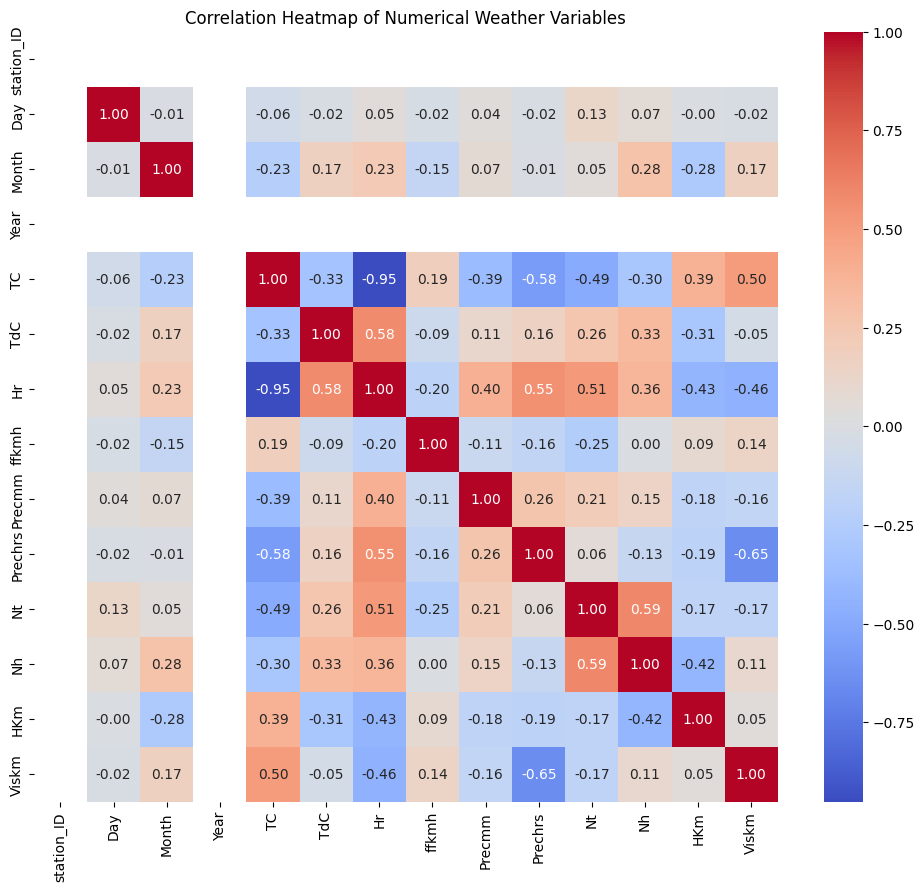

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_df = df_cleaned.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Weather Variables')
plt.show()

### (c) Discuss any three data mining algorithm approaches you can use to analyze your data.

Given the nature of this weather dataset, which is a time series with various meteorological parameters, several data mining approaches could be highly beneficial. Here are three approaches:

1.  **Time Series Forecasting (e.g., ARIMA, Prophet, LSTM):**
    *   **Description:** This approach focuses on predicting future values of a time series based on historical data. Algorithms like ARIMA (AutoRegressive Integrated Moving Average) are statistical methods that model the relationship between an observation and a number of lagged observations and a lagged forecast error. Facebook Prophet is a procedure for forecasting univariate time series data, which is robust to missing data and shifts in the time series. Deep learning models like LSTMs (Long Short-Term Memory networks) are particularly adept at capturing complex temporal dependencies in sequence data.
    *   **Applicability:** This would be ideal for predicting future weather conditions such as temperature, humidity, or precipitation, which are crucial for planning and risk management. For instance, predicting daily maximum temperatures or hourly precipitation rates.

2.  **Clustering (e.g., K-Means, Hierarchical Clustering, DBSCAN):**
    *   **Description:** Clustering algorithms are unsupervised learning techniques that group similar data points together. They identify inherent groupings within the data without prior knowledge of labels. K-Means partitions data into k clusters, Hierarchical Clustering builds a hierarchy of clusters, and DBSCAN groups together points that are closely packed together, marking as outliers points that lie alone in low-density regions.
    *   **Applicability:** Clustering could be used to identify different weather patterns or regimes throughout the year. For example, grouping days with similar temperature, humidity, and wind conditions to identify "dry spells," "rainy seasons," or "heatwaves." This can help in understanding seasonal variations or unusual weather events.

3.  **Regression Analysis (e.g., Linear Regression, Random Forest Regressor, Gradient Boosting Regressor):**
    *   **Description:** Regression analysis is a supervised learning technique used to model the relationship between a dependent variable and one or more independent variables. It aims to predict a continuous output. Linear Regression finds a linear relationship, while ensemble methods like Random Forest and Gradient Boosting can capture non-linear relationships and interactions between features, often providing higher predictive accuracy.
    *   **Applicability:** This approach could be used to model and predict one weather variable based on others. For example, predicting 'TC' (Temperature in Celsius) based on 'TdC' (Dew Point Temperature), 'Hr' (Humidity), and 'Precmm' (Precipitation in mm). This could help in understanding the drivers of certain weather phenomena or even in predicting missing values if they were not imputed.

### (d) Use one of the approaches discussed in (c).

#### i. Determine the model that relate the variables.

I will use **Linear Regression** to model the relationship between 'TC' (Temperature in Celsius) and other highly correlated features identified earlier, such as 'Hr' (Humidity), 'TdC' (Dew Point Temperature), and 'Precmm' (Precipitation in mm).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features (X) and target (y)
# Based on correlation analysis, 'Hr', 'TdC', 'Precmm', 'Viskm' showed significant correlations with 'TC'.
# 'Year' and 'station_ID' are constants or have NaN correlations, so they are not useful as predictors.
# 'Day' and 'Month' could be useful but for simplicity, we start with numerical weather parameters.
features = ['Hr', 'TdC', 'Precmm', 'Viskm']
X = df_cleaned[features]
y = df_cleaned['TC']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Model Trained.")
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")

Linear Regression Model Trained.
Model coefficients: [-0.23349261  0.8487427   0.01458737 -0.00743677]
Model intercept: 25.169397185613786


#### ii. Evaluate the model with appropriate performance metrics.

Now, let's evaluate the performance of our Linear Regression model using common metrics such as R-squared, Mean Absolute Error (MAE), and Mean Squared Error (MSE).

Mean Absolute Error (MAE): 0.30
Mean Squared Error (MSE): 0.21
R-squared (R2): 0.97


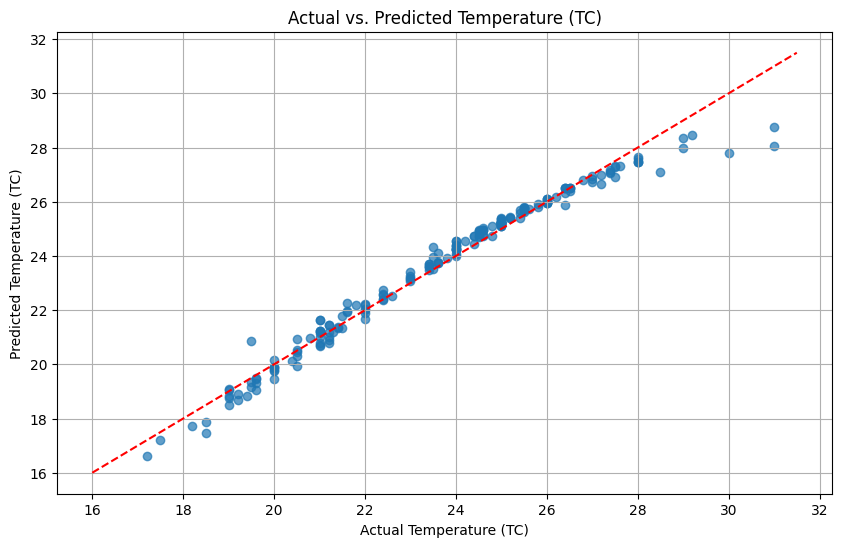

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Temperature (TC)')
plt.ylabel('Predicted Temperature (TC)')
plt.title('Actual vs. Predicted Temperature (TC)')
plt.grid(True)
plt.show()